<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Advanced_Composite_Biomaterials_Accelerate_Tissue_Reconstruction_Overcoming_High_Rejection_Rates_and_Mechanical_Weaknesses_in_Engineered_Tissue_Scaffolds_for_Wound_Repair.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Advanced Composite Biomaterials Accelerate Tissue Reconstruction: Overcoming High Rejection Rates and Mechanical Weaknesses in Engineered Tissue Scaffolds for Wound Repair

Since no specific dataset was provided, I will generate a synthetic dataset to demonstrate data loading and visualization in the context of advanced composite biomaterials.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a synthetic dataset for biomaterial scaffolds
np.random.seed(42)
num_samples = 100

data = {
    'material_type': np.random.choice(['Hydrogel-A', 'Hydrogel-B', 'Bioceramic-A', 'Bioceramic-B', 'Polymer-A', 'Polymer-B'], num_samples),
    'composite_ratio': np.random.uniform(0.1, 0.9, num_samples),
    'mechanical_strength_mpa': np.random.normal(50, 15, num_samples), # MPa
    'rejection_rate_percent': np.random.normal(10, 3, num_samples), # % (lower is better)
    'regeneration_time_days': np.random.normal(30, 7, num_samples), # days (lower is better)
    'cell_viability_percent': np.random.normal(85, 5, num_samples), # % (higher is better)
    'cost_per_unit': np.random.normal(100, 20, num_samples) # arbitrary cost unit
}

# Introduce some variability and relationships based on material type
df = pd.DataFrame(data)

df.loc[df['material_type'].str.contains('Hydrogel'), 'rejection_rate_percent'] -= np.random.uniform(0, 3)
df.loc[df['material_type'].str.contains('Bioceramic'), 'mechanical_strength_mpa'] += np.random.uniform(0, 20)
df.loc[df['material_type'].str.contains('Polymer'), 'regeneration_time_days'] += np.random.uniform(0, 5)

df['mechanical_strength_mpa'] = df['mechanical_strength_mpa'].apply(lambda x: max(10, x))
df['rejection_rate_percent'] = df['rejection_rate_percent'].apply(lambda x: max(1, x))
df['regeneration_time_days'] = df['regeneration_time_days'].apply(lambda x: max(10, x))
df['cell_viability_percent'] = df['cell_viability_percent'].apply(lambda x: min(99, max(70, x)))

print("Synthetic dataset created successfully.")


Synthetic dataset created successfully.


In [2]:
# Display the first 5 rows of the synthetic dataset
display(df.head())

,material_type,composite_ratio,mechanical_strength_mpa,rejection_rate_percent,regeneration_time_days,cell_viability_percent,cost_per_unit
0,Bioceramic-B,0.741758,82.525994,14.681140,34.296889,83.593074,77.217165
1,Polymer-A,0.159641,63.103841,10.385653,41.239932,76.676534,105.354853
2,Bioceramic-A,0.889510,57.064085,11.648729,26.966876,84.969004,155.675548
3,Polymer-A,0.717796,44.516911,6.187385,33.161525,87.015597,67.779888
4,Polymer-A,0.258973,59.736301,17.167108,35.648530,90.613388,97.028972


### Data Exploration: Visualizing Insights from Biomaterial Scaffolds

Let's visualize some key relationships within our synthetic dataset to understand the characteristics of different biomaterial types.

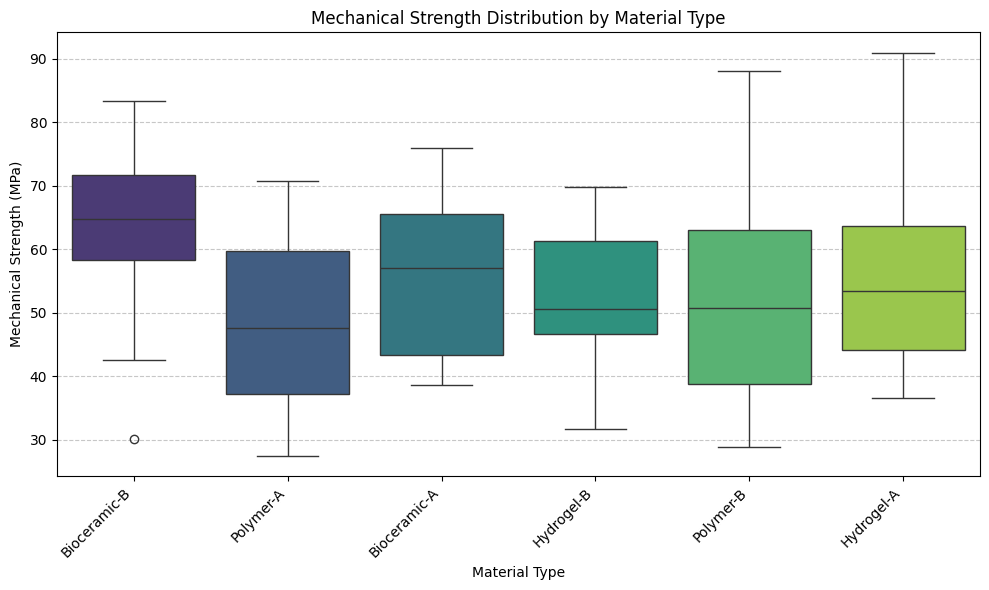

In [6]:
# 1. Distribution of Mechanical Strength by Material Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='material_type', y='mechanical_strength_mpa', data=df, palette='viridis', hue='material_type', legend=False)
plt.title('Mechanical Strength Distribution by Material Type')
plt.xlabel('Material Type')
plt.ylabel('Mechanical Strength (MPa)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

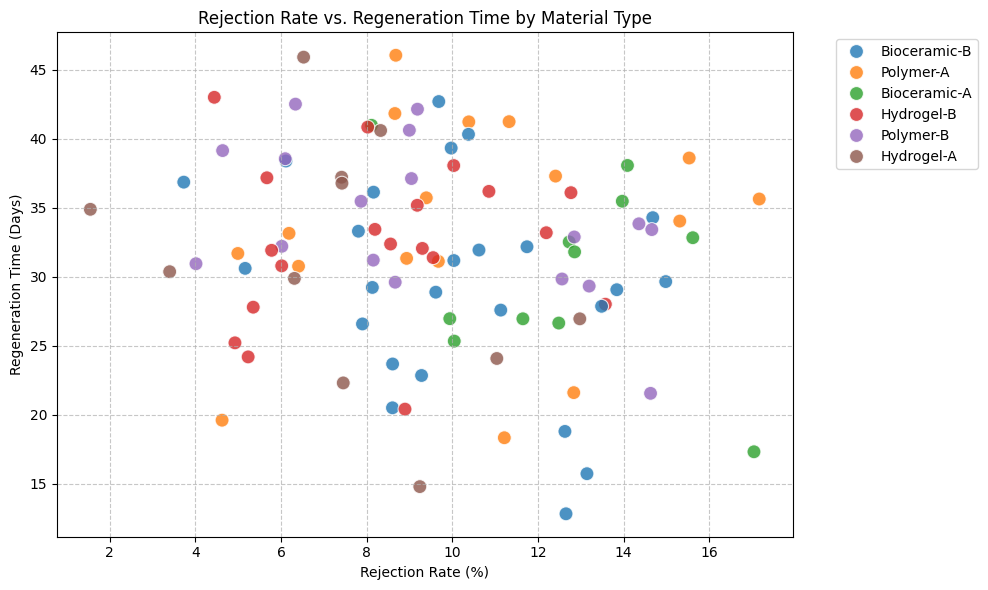

In [4]:
# 2. Relationship between Rejection Rate and Regeneration Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rejection_rate_percent', y='regeneration_time_days', hue='material_type', data=df, s=100, alpha=0.8, palette='tab10')
plt.title('Rejection Rate vs. Regeneration Time by Material Type')
plt.xlabel('Rejection Rate (%)')
plt.ylabel('Regeneration Time (Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

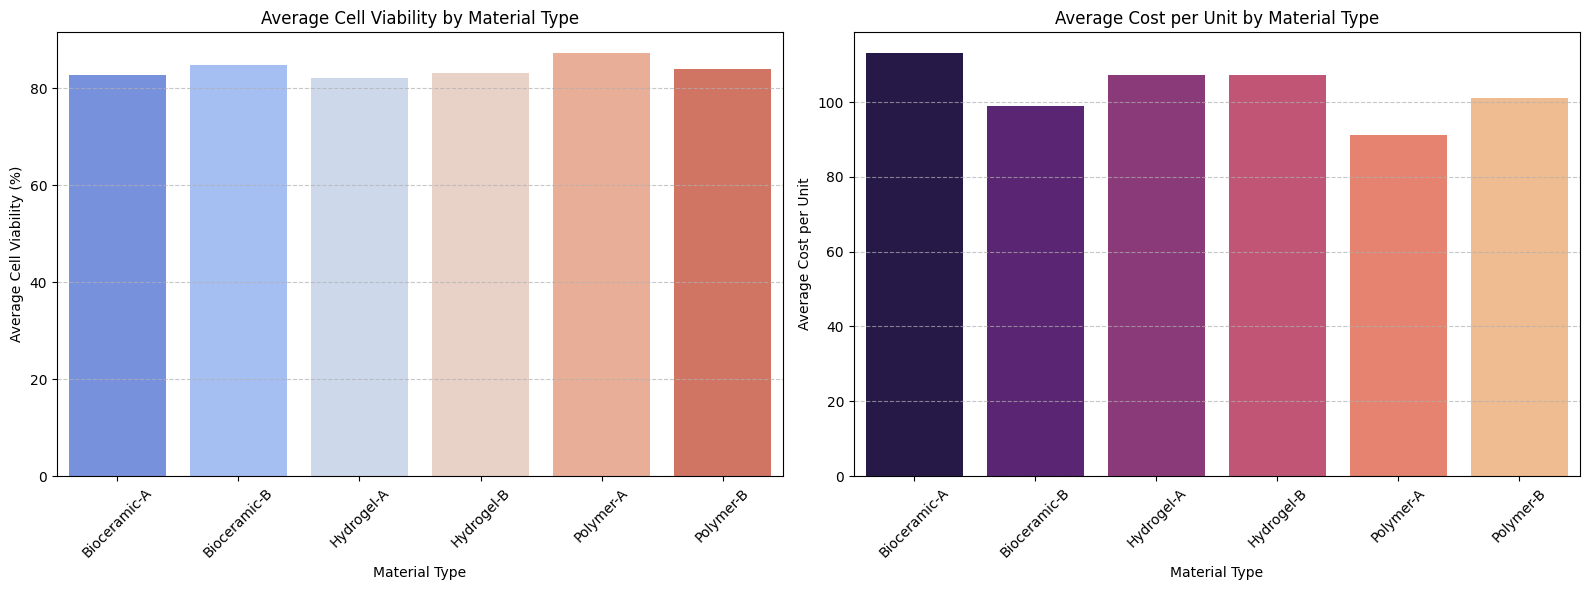

In [7]:
# 3. Average Cell Viability and Cost per Material Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='material_type', y='cell_viability_percent', data=df.groupby('material_type')['cell_viability_percent'].mean().reset_index(), palette='coolwarm', ax=axes[0], hue='material_type', legend=False)
axes[0].set_title('Average Cell Viability by Material Type')
axes[0].set_xlabel('Material Type')
axes[0].set_ylabel('Average Cell Viability (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='material_type', y='cost_per_unit', data=df.groupby('material_type')['cost_per_unit'].mean().reset_index(), palette='magma', ax=axes[1], hue='material_type', legend=False)
axes[1].set_title('Average Cost per Unit by Material Type')
axes[1].set_xlabel('Material Type')
axes[1].set_ylabel('Average Cost per Unit')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Correlation Heatmap of Numerical Features

Let's visualize the correlation between the numerical features to identify strong positive or negative relationships. This can provide insights into how changes in one property might affect others.

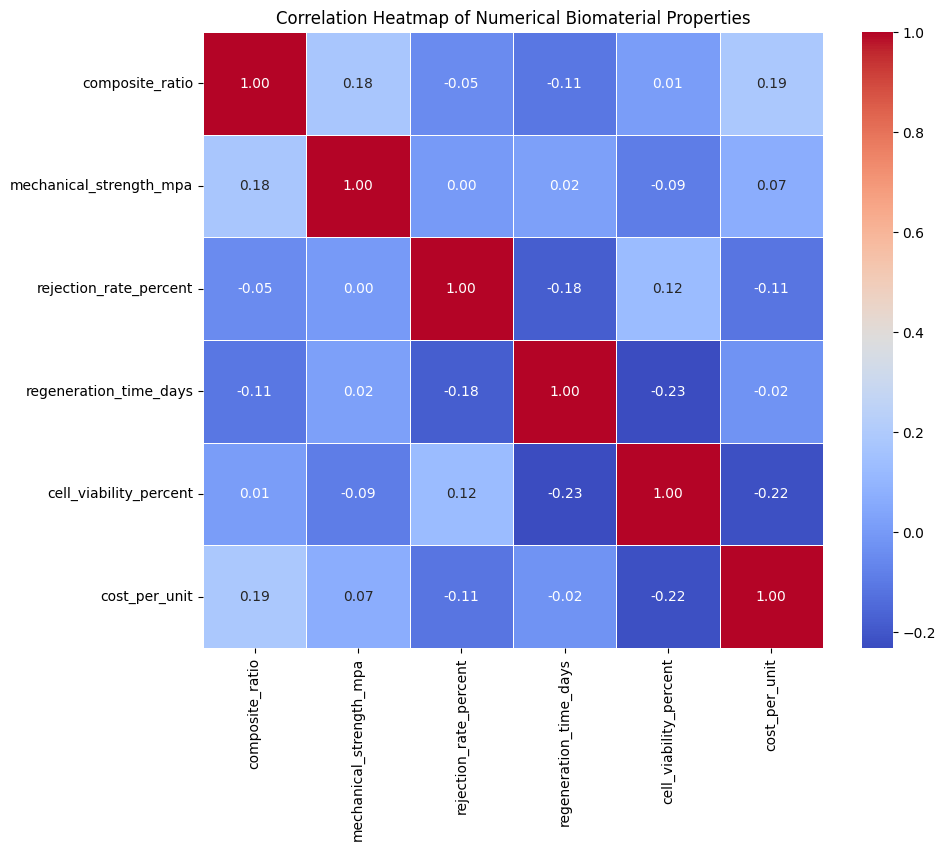

In [8]:
# Calculate the correlation matrix for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Biomaterial Properties')
plt.show()

### Regression Analysis: Mechanical Strength vs. Regeneration Time

Let's perform a regression analysis to observe the relationship between the mechanical strength of the biomaterials and the tissue regeneration time. A regression line can indicate the trend and strength of this relationship.

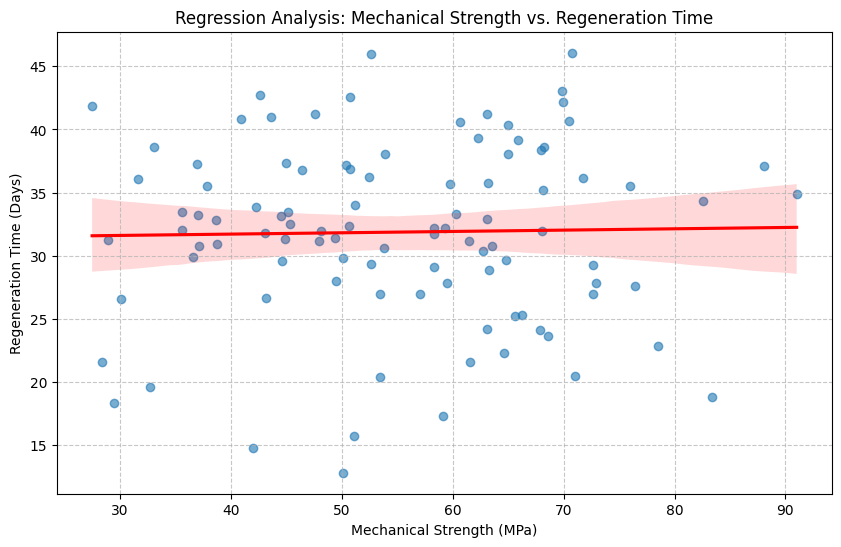

In [9]:
# Regression analysis: Mechanical Strength vs. Regeneration Time
plt.figure(figsize=(10, 6))
sns.regplot(x='mechanical_strength_mpa', y='regeneration_time_days', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regression Analysis: Mechanical Strength vs. Regeneration Time')
plt.xlabel('Mechanical Strength (MPa)')
plt.ylabel('Regeneration Time (Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Mean Values by Material Type

Let's group the data by `material_type` and calculate the mean of each numerical property. This provides an aggregated view of the typical characteristics of each biomaterial category.

In [10]:
# Group by material_type and calculate mean values
material_type_means = df.groupby('material_type')[numerical_cols].mean().reset_index()
display(material_type_means)

,material_type,composite_ratio,mechanical_strength_mpa,rejection_rate_percent,regeneration_time_days,cell_viability_percent,cost_per_unit
0,Bioceramic-A,0.571550,55.447022,12.594707,30.457863,82.582998,113.001706
1,Bioceramic-B,0.478475,63.441574,10.084504,29.630021,84.827910,98.840249
2,Hydrogel-A,0.640420,55.907205,7.424358,31.265724,82.150284,107.367371
3,Hydrogel-B,0.485919,51.993705,8.345101,32.503401,83.178789,107.145865
4,Polymer-A,0.415366,48.214879,10.219976,33.497898,87.123308,91.227216
5,Polymer-B,0.443019,52.523588,9.487123,34.153459,84.001173,101.024441


### Distribution of Cell Viability by Material Type

To further understand the performance of each biomaterial, let's visualize the distribution of `cell_viability_percent` for each `material_type`. This will show us not just the average, but also the spread and density of viability scores.

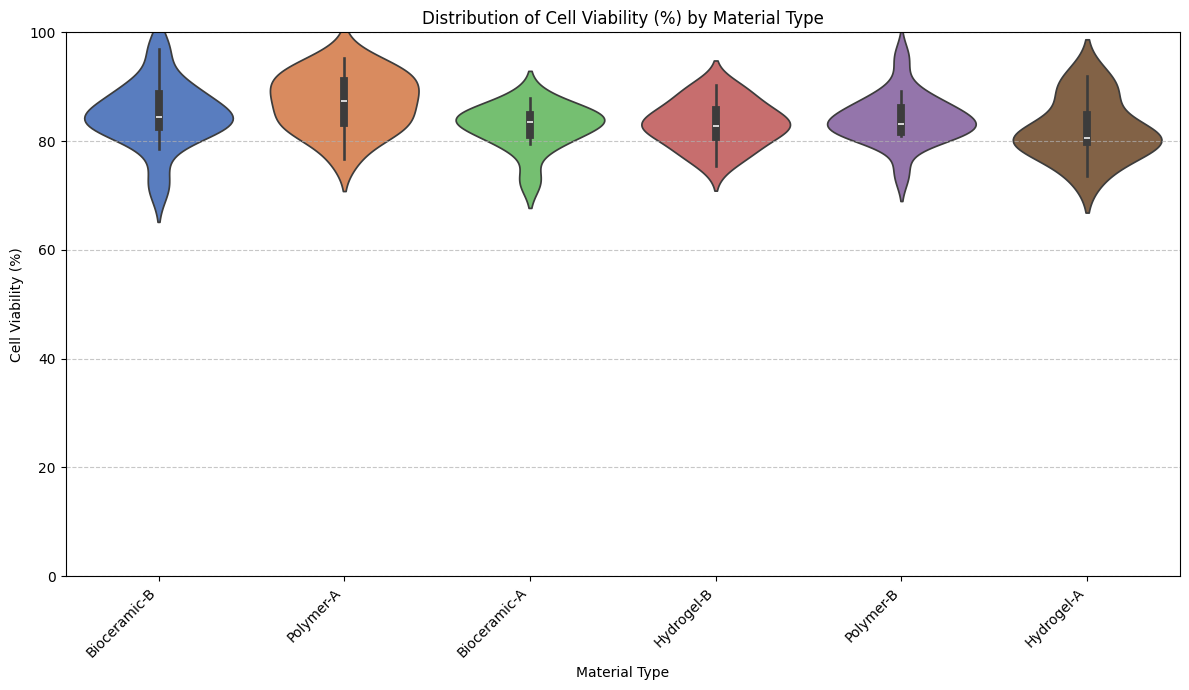

In [11]:
# Visualize the distribution of cell viability across all material types
plt.figure(figsize=(12, 7))
sns.violinplot(x='material_type', y='cell_viability_percent', data=df, palette='muted', hue='material_type', legend=False)
plt.title('Distribution of Cell Viability (%) by Material Type')
plt.xlabel('Material Type')
plt.ylabel('Cell Viability (%)')
plt.ylim(0, 100) # Set y-axis limits to 0-100 for percentage
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Relationship Between Rejection Rate and Cell Viability

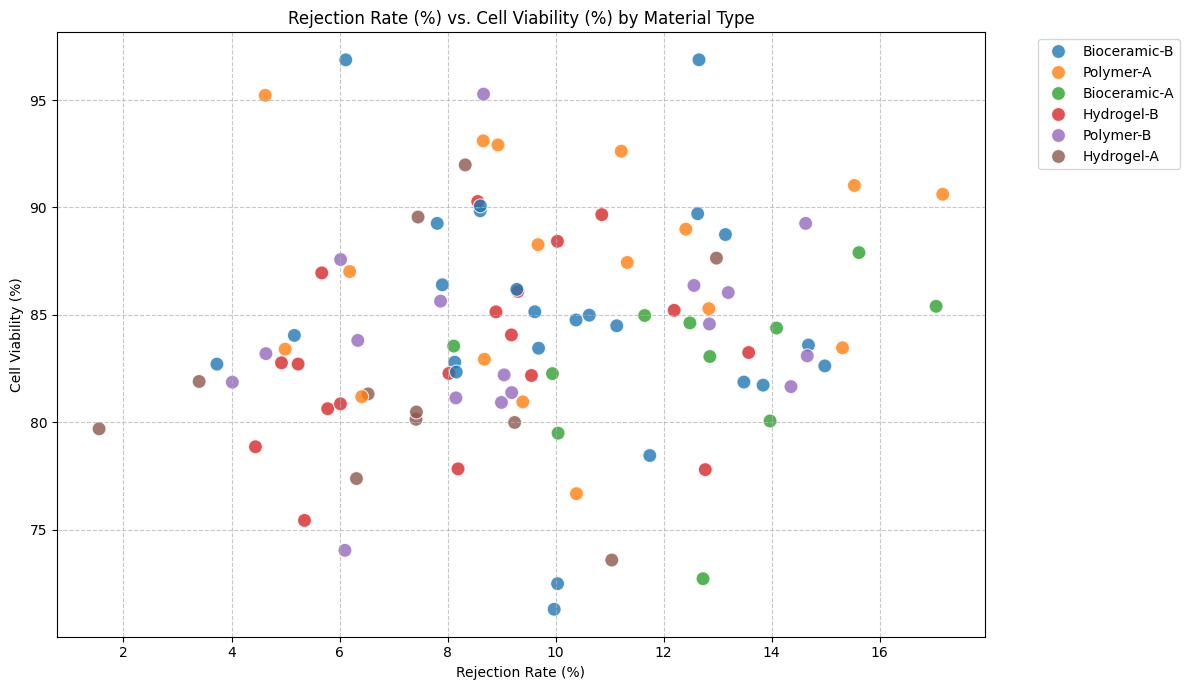

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='rejection_rate_percent', y='cell_viability_percent', hue='material_type', data=df, s=100, alpha=0.8, palette='tab10')
plt.title('Rejection Rate (%) vs. Cell Viability (%) by Material Type')
plt.xlabel('Rejection Rate (%)')
plt.ylabel('Cell Viability (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Recalculating Correlation Matrix

In [13]:
# Calculate the correlation matrix for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()
display(correlation_matrix)

,composite_ratio,mechanical_strength_mpa,rejection_rate_percent,regeneration_time_days,cell_viability_percent,cost_per_unit
composite_ratio,1.000000,0.177432,-0.047472,-0.109471,0.010113,0.186606
mechanical_strength_mpa,0.177432,1.000000,0.000604,0.021281,-0.090597,0.067701
rejection_rate_percent,-0.047472,0.000604,1.000000,-0.181569,0.124966,-0.114983
regeneration_time_days,-0.109471,0.021281,-0.181569,1.000000,-0.231203,-0.022667
cell_viability_percent,0.010113,-0.090597,0.124966,-0.231203,1.000000,-0.218602
cost_per_unit,0.186606,0.067701,-0.114983,-0.022667,-0.218602,1.000000


### Regression Analysis: Regeneration Time vs. Cell Viability

Let's examine the relationship between `regeneration_time_days` and `cell_viability_percent` with a regression plot.

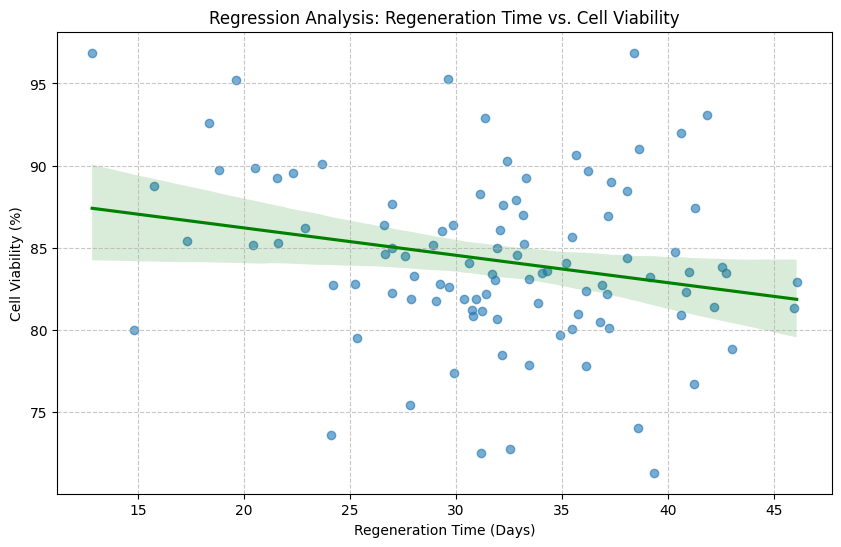

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x='regeneration_time_days', y='cell_viability_percent', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'green'})
plt.title('Regression Analysis: Regeneration Time vs. Cell Viability')
plt.xlabel('Regeneration Time (Days)')
plt.ylabel('Cell Viability (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pairplot of Numerical Variables

To get a quick overview of the relationships between all numerical variables and their individual distributions, let's generate a pairplot.

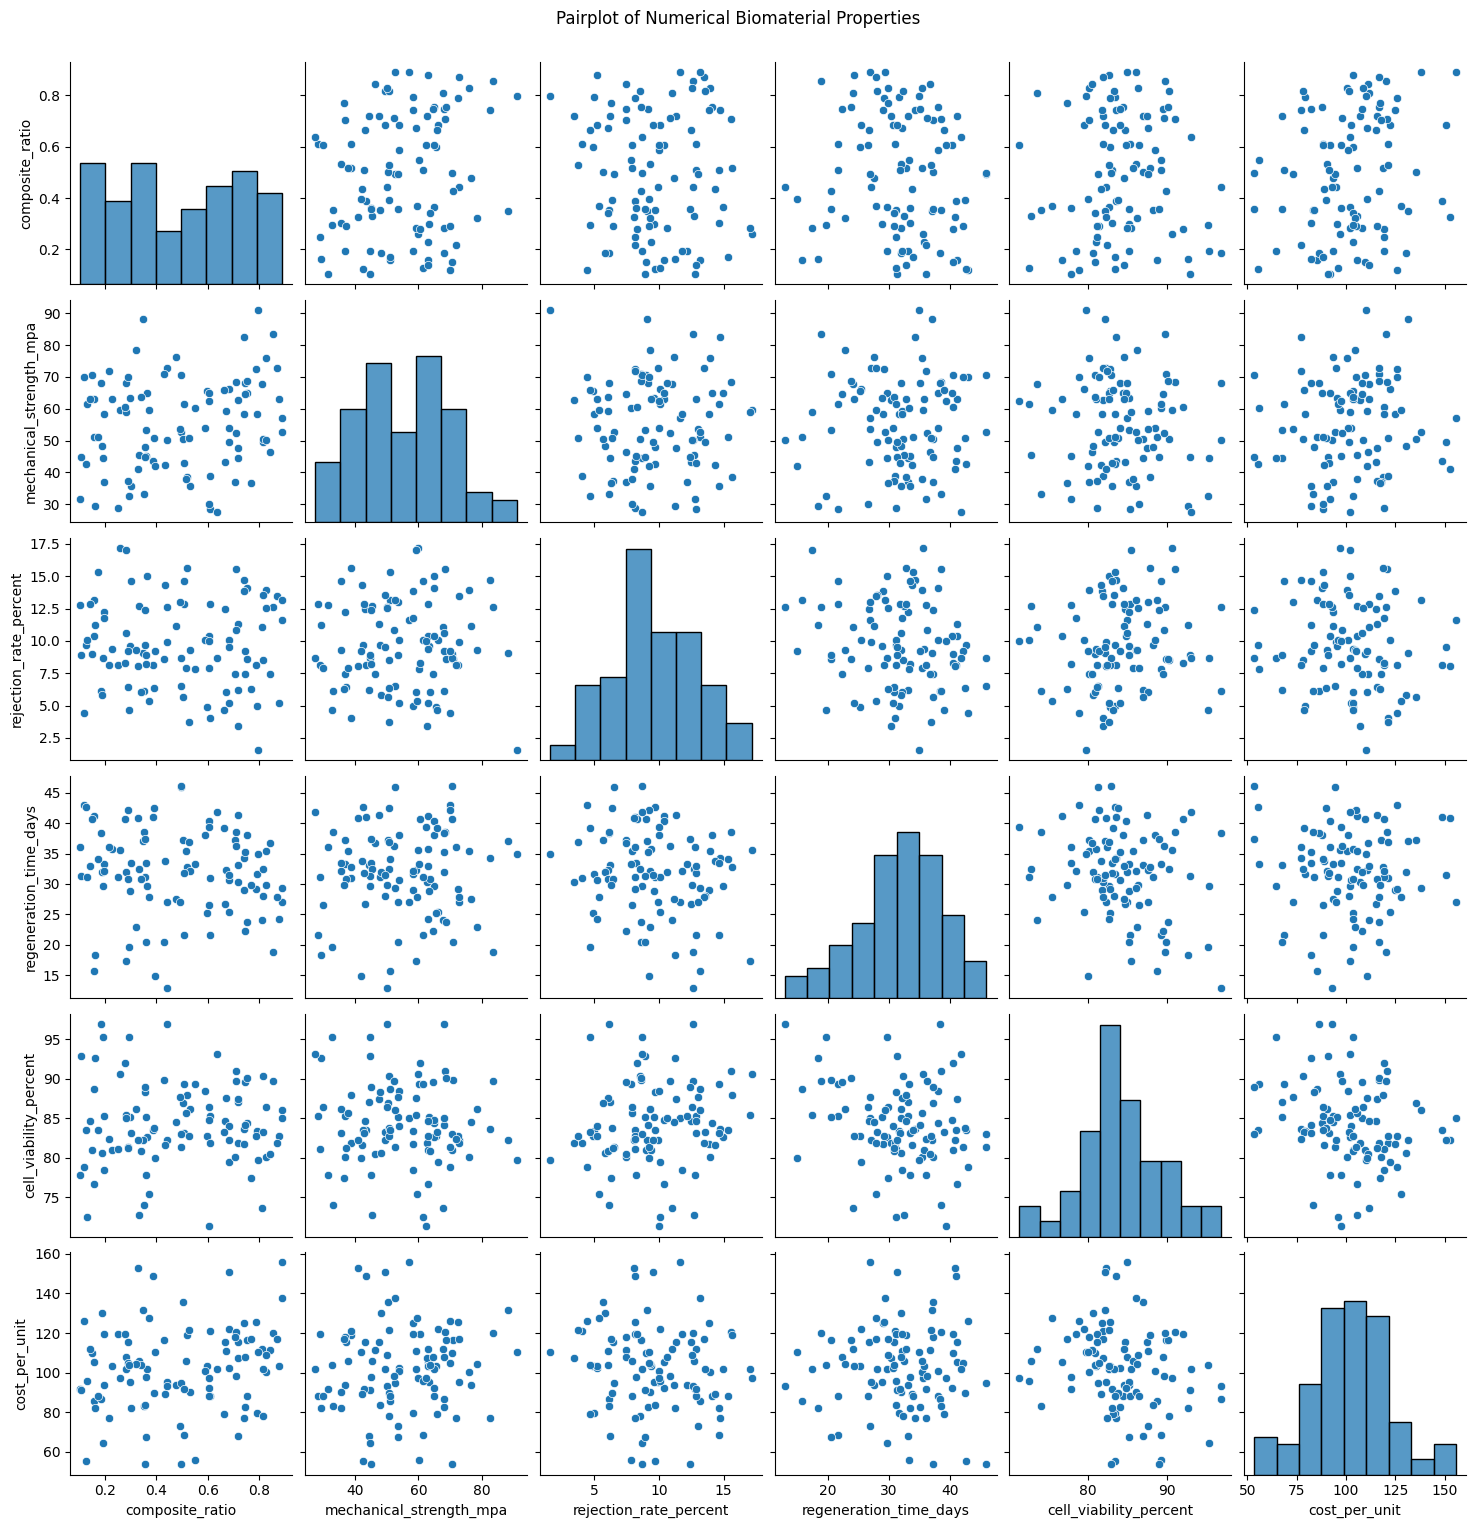

In [17]:
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Biomaterial Properties', y=1.02) # Adjust suptitle to not overlap with titles
plt.show()

### Outlier Detection using Boxplots

Boxplots are useful for visualizing the distribution of numerical data and identifying potential outliers. Let's generate a boxplot for each numerical column.

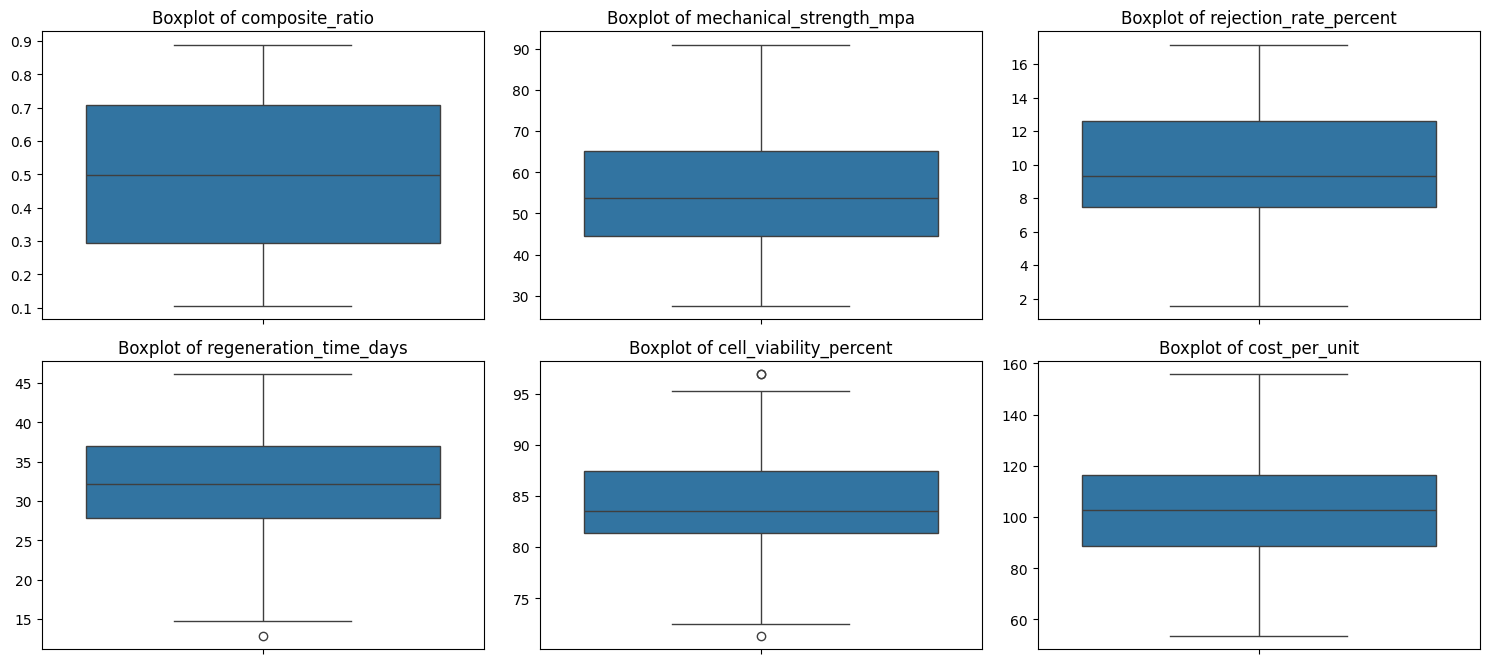

In [19]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df[col]) # Removed palette argument
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()